# Experiment 1: clean reliability sign-gate factorial

This notebook is an unexecuted fork of notebook 13 for the primary clean sign-gate test. It uses $K=3$, and every question set is sampled subject to exactly one of the two candidates belonging to each displayed set. Consequently $a(C_1)+a(C_2)=K$ and $\Delta a=a(C_1)-a(C_2)$ is always odd and nonzero. The $r=.5$ rows remain a separately labeled continuous null; every other configured reliability has a strict Bayesian winner.

The experiment crosses 32 independently sampled question schedules, all $2^K$ report patterns, the three interior symmetric reliability pairs $(.1,.9)$, $(.25,.75)$, and $(.4,.6)$, both candidate orders, and two prompt representations: the raw set-membership transcript and the framework's candidate-specific `AGREES`/`DISAGREES` transcript. Both conditions request an immediate answer with native thinking disabled. Agreement vectors already live in every transcript row, so this notebook does not construct a separate candidate-factor-list condition.

Each selected model receives $2 \times 7 \times 32 \times 2^3 \times 2=7{,}168$ inference rows. The runner preserves the exact completion, locates the generated `ANSWER:` boundary, and teacher-forces the emitted sequence to obtain answer-surface logits. Malformed rows remain compliance observations and are never repaired.

In [1]:
from __future__ import annotations

import csv
import gc
import hashlib
import json
import logging
import math
import os
import random
import re
import sys
import threading
from collections import Counter, defaultdict
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from statistics import correlation, fmean
from time import monotonic

# Set before importing Transformers, which may probe optional torchao backends.
os.environ.setdefault("TORCHAO_FORCE_SKIP_LOADING_SO_FILES", "1")
logging.getLogger("torchao").setLevel(logging.ERROR)

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display
from transformers import AutoProcessor

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from mats_experiments.noisy_channel_bayesian import (
    CandidateEvidenceBayesianEnvironment,
    CandidateEvidenceDatasetGenerator,
    CandidateEvidenceQuestion,
    CaptureSpec,
    ExecutionConfig,
    MetricSpec,
    ModelConfig,
    NoisyChannelBayesianEnvironment,
    QwenRunner,
    RandomSubsetQuestion,
    SGLangMTPConfig,
    SystemPrompt,
    TokenizerBinding,
    TranscriptDataset,
    TranscriptDatasetGenerator,
    XVsYPosteriorProbe,
    answer_patterns,
    get_answer_surface_logits,
)

## Configuration

`MODEL_SELECTION` accepts one model ID or a list. `R_VALUES` contains only interior symmetric pairs plus the separately analyzed $r=.5$ null. `NUM_QUESTION_SETS=32` is the schedule-level sampling count. `REPRESENTATIONS` compares the original prompt to the direct agreement-relation prompt; no visible reasoning or native thinking condition is included.

This new experiment has no saved run initially, so `LOAD_RESULTS_FROM_ARTIFACTS=False`. Running this cell alone is safe; the load/generate cell below is the cell that starts inference. After a completed run exists, set the flag to `True` to analyze it without loading a model.

In [2]:
N = 8
K = 3
R_VALUES = (0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9)
SYMMETRIC_R_PAIRS = (("1/10", "9/10"), ("1/4", "3/4"), ("2/5", "3/5"))
NULL_R = "1/2"
NUM_QUESTION_SETS = 32
CONTROL_POSITIONAL_BIAS = True
REPRESENTATIONS = ("raw", "candidate_evidence")
REPRESENTATION_LABELS = {
    "raw": "Raw sets/reports",
    "candidate_evidence": "AGREES/DISAGREES",
}
ENABLE_MTP = True
SIGN_GATE_BOOTSTRAP_REPLICATES = 10_000

SYSTEM_PROMPT_TEXT = (
    "You are a Bayesian reasoner. Follow the user's game rules exactly. "
    "Use plaintext only. Do not use Markdown, headings, bullets, tables, code blocks, "
    "HTML, or any other formatting."
)
MODEL_SELECTION: str | list[str] = ["Qwen/Qwen3.5-9B"]

X = 2
Y = 7
SUBSET_SIZE = 4
SEED = 20260904

MODEL_DTYPE = "auto"
DEVICE_MAP = None
LOCAL_FILES_ONLY = True
LOAD_RESULTS_FROM_ARTIFACTS = False
MAX_COMPLETION_TOKENS = 128
CHECKPOINT_EVERY_BATCHES = 25
LOG_INTERVAL_SECONDS = 30
EXPERIMENT_ROOT = REPO_ROOT / "artifacts" / "noisy_channel_bayesian_experiment_1_sign_gate"

SGLANG_PYTHON = REPO_ROOT / ".venv-sglang" / "bin" / "python"
COMPLETION_MTP_BY_MODEL = {
    "Qwen/Qwen3.5-4B": SGLangMTPConfig(
        enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON,
        speculative_num_steps=3, speculative_eagle_topk=1,
        speculative_num_draft_tokens=4, context_length=8192,
        cuda_graph_max_batch_size=48,
    ),
    "Qwen/Qwen3.5-9B": SGLangMTPConfig(
        enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON,
        speculative_num_steps=3, speculative_eagle_topk=1,
        speculative_num_draft_tokens=4, context_length=8192,
        cuda_graph_max_batch_size=24,
    ),
}
DEFAULT_COMPLETION_MTP = SGLangMTPConfig(
    enabled=ENABLE_MTP, python_executable=SGLANG_PYTHON, context_length=8192,
)
RUN_ID = "clean_sign_gate_k3_immediate_v1_" + (
    "mtp" if ENABLE_MTP else "transformers"
)
BATCH_SIZES_BY_MODEL = {
    "Qwen/Qwen3.5-4B": {"completion": 40, "capture": 4, "score": 16},
    "Qwen/Qwen3.5-9B": {"completion": 24, "capture": 2, "score": 8},
}
DEFAULT_BATCH_SIZES = {"completion": 4, "capture": 1, "score": 4}

In [3]:
def log_progress(message: str) -> None:
    timestamp = datetime.now(UTC).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{timestamp}] {message}", flush=True)


def checkpoint_row_count(path: Path) -> int:
    if not path.exists():
        return 0
    try:
        with path.open("r", encoding="utf-8") as handle:
            return sum(bool(line.strip()) for line in handle)
    except OSError:
        return 0


@contextmanager
def progress_heartbeat(
    label: str, checkpoint_path: Path | None = None, *, expected_rows: int
):
    started = monotonic()
    stopped = threading.Event()

    def report() -> None:
        while not stopped.wait(LOG_INTERVAL_SECONDS):
            suffix = ""
            if checkpoint_path is not None:
                suffix = (
                    f"; completed rows={checkpoint_row_count(checkpoint_path)}/"
                    f"{expected_rows}"
                )
            log_progress(
                f"{label}: still running; elapsed={(monotonic() - started) / 60:.1f} min"
                f"{suffix}"
            )

    log_progress(f"{label}: started")
    worker = threading.Thread(target=report, name=f"{label}-heartbeat", daemon=True)
    worker.start()
    succeeded = False
    try:
        yield
        succeeded = True
    finally:
        stopped.set()
        worker.join(timeout=1)
        status = "finished" if succeeded else "stopped with an error"
        log_progress(
            f"{label}: {status} after {(monotonic() - started) / 60:.1f} min"
        )


def normalize_model_ids(selection: str | list[str]) -> list[str]:
    values = [selection] if isinstance(selection, str) else list(selection)
    if not values or not all(isinstance(value, str) and value.strip() for value in values):
        raise ValueError("MODEL_SELECTION must contain non-empty model IDs.")
    if len(values) != len(set(values)):
        raise ValueError("MODEL_SELECTION contains a duplicate model ID.")
    return values


def model_key(model_id: str) -> str:
    readable = re.sub(r"[^A-Za-z0-9_.-]+", "_", model_id).strip("_")
    digest = hashlib.sha256(model_id.encode()).hexdigest()[:8]
    return f"{readable}_{digest}"


@dataclass(frozen=True)
class ExclusiveCandidateSubsetQuestion(RandomSubsetQuestion):
    """Sample sets conditioned on containing exactly one focal candidate."""

    x: int = X
    y: int = Y

    def sample(self, *, rng: random.Random, n: int, k: int) -> list[dict[str, object]]:
        self.validate(n)
        if self.replacement:
            raise ValueError("The clean sign-gate sampler requires replacement=False.")
        if self.x == self.y or self.x not in range(1, n + 1) or self.y not in range(1, n + 1):
            raise ValueError("x and y must be distinct members of the domain.")
        if self.subset_size >= n:
            raise ValueError("subset_size must leave room to exclude one focal candidate.")
        domain = list(range(1, n + 1))
        sampled: list[dict[str, object]] = []
        for _ in range(k):
            while True:
                raw = rng.sample(domain, self.subset_size)
                if (self.x in raw) != (self.y in raw):
                    membership = sorted(raw) if self.sort else list(raw)
                    sampled.append({"raw_draws": raw, "membership_set": membership})
                    break
        return sampled


MODEL_IDS = normalize_model_ids(MODEL_SELECTION)
raw_environments = tuple(
    NoisyChannelBayesianEnvironment(
        n=N, k=K, r_values=reliability,
        control_positional_bias=CONTROL_POSITIONAL_BIAS,
    )
    for reliability in R_VALUES
)
R_EXACT_VALUES = tuple(
    f"{environment.reliabilities[0].numerator}/{environment.reliabilities[0].denominator}"
    for environment in raw_environments
)
evidence_environments = {
    exact: CandidateEvidenceBayesianEnvironment(
        n=N, k=K, r_values=reliability,
        control_positional_bias=CONTROL_POSITIONAL_BIAS,
    )
    for exact, reliability in zip(R_EXACT_VALUES, R_VALUES, strict=True)
}
R_FLOAT_BY_EXACT = {
    exact: float(environment.reliabilities[0])
    for exact, environment in zip(R_EXACT_VALUES, raw_environments, strict=True)
}
R_INDEX_BY_EXACT = {value: index for index, value in enumerate(R_EXACT_VALUES)}
question = ExclusiveCandidateSubsetQuestion(
    subset_size=SUBSET_SIZE, replacement=False, sort=True, x=X, y=Y
)
probe = XVsYPosteriorProbe(
    x=X, y=Y, reasoning=False, allow_same=False, call_layout="conversation"
)
evidence_question = CandidateEvidenceQuestion()
system_prompt = SystemPrompt(SYSTEM_PROMPT_TEXT)
metric_spec = MetricSpec(sequence_scores=False)
capture_spec = CaptureSpec(
    logits_boundaries=("answer",),
    logits_scope="answer_surfaces",
    every_decode_position=False,
)

assert K % 2 == 1
assert all(low in R_EXACT_VALUES and high in R_EXACT_VALUES for low, high in SYMMETRIC_R_PAIRS)
assert NULL_R in R_EXACT_VALUES
assert all(environment.shared_reliability for environment in raw_environments)
assert CONTROL_POSITIONAL_BIAS and not probe.reasoning and not probe.allow_same
assert all(config.enabled is ENABLE_MTP for config in COMPLETION_MTP_BY_MODEL.values())
EXPECTED_ROWS_PER_REPRESENTATION = len(R_VALUES) * NUM_QUESTION_SETS * 2**K * 2
EXPECTED_INFERENCE_ROWS_PER_MODEL = (
    len(REPRESENTATIONS) * EXPECTED_ROWS_PER_REPRESENTATION
)
print({
    "models": MODEL_IDS,
    "representations": REPRESENTATIONS,
    "reliability_values": R_VALUES,
    "question_schedules": NUM_QUESTION_SETS,
    "load_results_from_artifacts": LOAD_RESULTS_FROM_ARTIFACTS,
    "mtp_enabled": ENABLE_MTP,
    "rows_per_representation": EXPECTED_ROWS_PER_REPRESENTATION,
    "inference_rows_per_model": EXPECTED_INFERENCE_ROWS_PER_MODEL,
    "artifact_root": str(EXPERIMENT_ROOT),
})

{'models': ['Qwen/Qwen3.5-9B'], 'representations': ('raw', 'candidate_evidence'), 'reliability_values': ('1/10', '1/4', '2/5', '1/2', '3/5', '3/4', '9/10'), 'question_schedules': 32, 'load_results_from_artifacts': False, 'mtp_enabled': True, 'rows_per_representation': 3584, 'inference_rows_per_model': 7168, 'artifact_root': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_1_sign_gate'}


## Non-tie construction and paired prompt validation

For every sampled question, exactly one of $C_1$ and $C_2$ belongs to the set. Therefore exactly one candidate agrees with each observed report, $a(C_1)+a(C_2)=3$, and $\Delta a\in\{-3,-1,1,3\}$. The validation below also checks that the reduced rows are exact projections of the raw rows, retain the same targets and positional pairing, expose only candidate-specific relations to the model, and keep raw sets/reports only under audit metadata.

In [4]:
def row_representation(row: dict[str, object]) -> str:
    return str(row.get("representation", "raw"))


def row_reliability_exact(row: dict[str, object]) -> str:
    values = tuple(str(value) for value in row["reliabilities_exact"])
    assert len(values) == K and len(set(values)) == 1
    return values[0]


def row_membership_sets(row: dict[str, object]) -> list[list[int]]:
    if "membership_sets" in row:
        return [list(values) for values in row["membership_sets"]]
    audit = row["audit_metadata"]
    return [list(values) for values in audit["membership_sets"]]


def row_observed_reports(row: dict[str, object]) -> list[str]:
    if "observed_reports" in row:
        return [str(value) for value in row["observed_reports"]]
    return [str(value) for value in row["audit_metadata"]["observed_reports"]]


def row_answer_pattern(row: dict[str, object]) -> str:
    if "answer_pattern" in row:
        return str(row["answer_pattern"])
    return str(row["audit_metadata"]["answer_pattern"])


def question_schedules(
    dataset: TranscriptDataset, reliability_exact: str
) -> list[list[list[int]]]:
    return [
        row_membership_sets(next(
            row for row in dataset
            if row["question_set_index"] == index
            and row_reliability_exact(row) == reliability_exact
        ))
        for index in range(NUM_QUESTION_SETS)
    ]


def validate_raw_dataset(dataset: TranscriptDataset) -> None:
    expected_patterns = [
        "".join("Y" if value == "YES" else "N" for value in pattern)
        for pattern in answer_patterns(K)
    ]
    assert len(dataset) == EXPECTED_ROWS_PER_REPRESENTATION
    assert dataset.manifest["environment_parameter_count"] == len(R_VALUES)
    assert dataset.manifest["parameterization_count"] == len(R_VALUES)
    assert dataset.manifest["probe_parameter_count"] == 1
    assert dataset.manifest["reasoning_values"] == [False]
    assert dataset.manifest["num_question_sets"] == NUM_QUESTION_SETS
    assert dataset.manifest["presentations_per_scenario"] == 2
    assert all(row_representation(row) == "raw" for row in dataset)
    assert all(row["n"] == N and row["k"] == K for row in dataset)
    assert all(row["candidate_1"] == X and row["candidate_2"] == Y for row in dataset)
    assert all(row["reasoning"] is False for row in dataset)

    schedules = {}
    for environment_index, reliability_exact in enumerate(R_EXACT_VALUES):
        selected = [
            row for row in dataset
            if row_reliability_exact(row) == reliability_exact
        ]
        assert len(selected) == NUM_QUESTION_SETS * 2**K * 2
        assert all(
            row["environment_parameter_index"] == environment_index
            for row in selected
        )
        schedules[reliability_exact] = question_schedules(dataset, reliability_exact)
        for question_set_index in range(NUM_QUESTION_SETS):
            rows = [
                row for row in selected
                if row["question_set_index"] == question_set_index
            ]
            assert [row_answer_pattern(row) for row in rows] == [
                pattern for pattern in expected_patterns for _ in range(2)
            ]
    reference_schedule = schedules[R_EXACT_VALUES[0]]
    assert all(schedule == reference_schedule for schedule in schedules.values())

    for row in dataset:
        sets = row_membership_sets(row)
        assert all((X in membership) != (Y in membership) for membership in sets)
        agreement_1 = int(row["total_agreement_candidate_1"])
        agreement_2 = int(row["total_agreement_candidate_2"])
        delta = agreement_1 - agreement_2
        assert agreement_1 + agreement_2 == K
        assert delta in {-3, -1, 1, 3}
        if row_reliability_exact(row) == NULL_R:
            assert row["normative_comparison"] == "SAME"
            assert row["ground_truth_choice"] is None
        else:
            assert row["normative_comparison"] != "SAME"
            assert row["ground_truth_choice"] in {"X", "Y"}
            assert row["canonical_ground_truth_choice"] in {"C1", "C2"}


def validate_candidate_evidence_dataset(
    raw_dataset: TranscriptDataset, reduced_dataset: TranscriptDataset
) -> None:
    assert len(reduced_dataset) == len(raw_dataset) == EXPECTED_ROWS_PER_REPRESENTATION
    raw_by_id = {str(row["row_id"]): row for row in raw_dataset}
    assert {str(row["source_row_id"]) for row in reduced_dataset} == set(raw_by_id)
    for reduced in reduced_dataset:
        assert row_representation(reduced) == "candidate_evidence"
        raw = raw_by_id[str(reduced["source_row_id"])]
        for field in (
            "question_set_index", "answer_pattern_index", "candidate_1", "candidate_2",
            "presentation_index", "presentation_order", "candidate_value_order",
            "reliabilities_exact", "prior_predictive_exact", "posterior_exact",
            "normative_comparison", "ground_truth_choice",
            "agreement_candidate_1_by_question", "agreement_candidate_2_by_question",
            "total_agreement_candidate_1", "total_agreement_candidate_2",
        ):
            assert reduced[field] == raw[field], field
        assert reduced["positional_control_pair_id"] == raw["positional_control_pair_id"]
        assert row_membership_sets(reduced) == row_membership_sets(raw)
        assert row_observed_reports(reduced) == row_observed_reports(raw)
        prompt_text = reduced["messages"][-1]["content"]
        assert "AGREES" in prompt_text and "DISAGREES" in prompt_text
        assert "Q1: Is s in" not in prompt_text and "SOURCE reported" not in prompt_text
        for candidate_index, candidate in ((1, X), (2, Y)):
            flags = reduced[f"agreement_candidate_{candidate_index}_by_question"]
            observations = reduced["candidate_evidence"][str(candidate)]["observations"]
            assert [item["relation"] == "AGREES" for item in observations] == [
                bool(value) for value in flags
            ]


def print_serialized_prompt_pair(
    raw_dataset: TranscriptDataset, reduced_dataset: TranscriptDataset, *, model_id: str
) -> None:
    raw = next(
        row for row in raw_dataset
        if row["question_set_index"] == 0
        and row["answer_pattern_index"] == 0
        and row["presentation_order"] == "C1_C2"
        and row_reliability_exact(row) == "1/10"
    )
    reduced = next(
        row for row in reduced_dataset if row["source_row_id"] == raw["row_id"]
    )
    print("\n" + "=" * 100)
    print(f"PAIRED SERIALIZED PROMPTS: {model_id}")
    print({
        "question_set_index": raw["question_set_index"],
        "answer_pattern": row_answer_pattern(raw),
        "reliability": row_reliability_exact(raw),
        "presentation_order": raw["presentation_order"],
        "membership_sets": row_membership_sets(raw),
        "observed_reports": row_observed_reports(raw),
        "agreement_c1": raw["agreement_candidate_1_by_question"],
        "agreement_c2": raw["agreement_candidate_2_by_question"],
    })
    for label, row in (("raw", raw), ("candidate_evidence", reduced)):
        print(f"\n--- representation={label} serialized_prompt ---")
        print(row["serialized_prompt"])
    print("=" * 100)

## Load saved results or generate the paired representations

With `LOAD_RESULTS_FROM_ARTIFACTS=True`, this section loads the separately saved raw and candidate-evidence datasets and their completed runs without instantiating a model. Otherwise, it generates the constrained raw schedule bank once, projects every raw row into the direct-agreement representation, and saves each representation under its own artifact directory. A valid completed representation is reused automatically; an interrupted representation resumes from its checkpoint. The two candidate numerals are checked to be single tokens before inference.

The answer-boundary procedure is unchanged from notebook 13. Both representations request only the terminal answer line, and native thinking remains disabled through `TokenizerBinding(enable_thinking=False)`. After each representation finishes answer-boundary scoring, its retained Transformers model is explicitly released before another SGLang process starts; this prevents two 9B model copies from overlapping on the GPU.

In [5]:
datasets_by_model: dict[str, dict[str, TranscriptDataset]] = {}
results_by_model: dict[str, dict[str, list[dict[str, object]]]] = {}
balanced_results_by_model: dict[str, dict[str, list[dict[str, object]]]] = {}
run_dirs_by_model: dict[str, dict[str, Path]] = {}


def build_candidate_evidence_dataset(
    raw_dataset: TranscriptDataset, binding: TokenizerBinding
) -> TranscriptDataset:
    reduced_rows: list[dict[str, object]] = []
    for reliability_exact in R_EXACT_VALUES:
        raw_slice = TranscriptDataset(
            [
                row for row in raw_dataset
                if row_reliability_exact(row) == reliability_exact
            ],
            manifest=raw_dataset.manifest,
        )
        reduced = CandidateEvidenceDatasetGenerator(
            environment=evidence_environments[reliability_exact],
            question=evidence_question,
            probe=probe,
            tokenizer_binding=binding,
            system_prompt=system_prompt,
        ).generate(source_dataset=raw_slice)
        reduced_rows.extend(reduced)
    manifest = {
        "schema_version": raw_dataset.manifest["schema_version"],
        "representation": "candidate_evidence",
        "source_row_count": len(raw_dataset),
        "num_question_sets": NUM_QUESTION_SETS,
        "patterns_per_question_set": 2**K,
        "presentations_per_scenario": 2,
        "control_positional_bias": CONTROL_POSITIONAL_BIAS,
        "n": N,
        "k": K,
        "reliabilities_exact": list(R_EXACT_VALUES),
        "reasoning_values": [False],
        "system_prompt": SYSTEM_PROMPT_TEXT,
        "tokenizer_template_fingerprint": binding.fingerprint,
    }
    return TranscriptDataset(reduced_rows, manifest=manifest)


def optional_mean(values: list[float | None]) -> float | None:
    return fmean(value for value in values if value is not None) if all(
        value is not None for value in values
    ) else None


def balance_positional_pairs(
    rows: list[dict[str, object]], *, representation: str
) -> list[dict[str, object]]:
    pairs = defaultdict(list)
    for row in rows:
        pairs[row["positional_control_pair_id"]].append(row)
    balanced_rows = []
    invariants = (
        "reasoning", "reliabilities_exact", "reliabilities", "question_set_index",
        "answer_pattern_index", "total_agreement_candidate_1",
        "total_agreement_candidate_2", "agreement_candidate_1_by_question",
        "agreement_candidate_2_by_question",
    )
    for pair_id, pair in pairs.items():
        by_order = {row["presentation_order"]: row for row in pair}
        assert set(by_order) == {"C1_C2", "C2_C1"}
        first, second = by_order["C1_C2"], by_order["C2_C1"]
        for field in invariants:
            assert first[field] == second[field], (pair_id, field)
        assert row_membership_sets(first) == row_membership_sets(second)
        assert row_observed_reports(first) == row_observed_reports(second)
        c1_values = [first["candidate_1_raw_logit"], second["candidate_1_raw_logit"]]
        c2_values = [first["candidate_2_raw_logit"], second["candidate_2_raw_logit"]]
        differences = [
            first["candidate_1_minus_candidate_2_raw_logit"],
            second["candidate_1_minus_candidate_2_raw_logit"],
        ]
        balanced = dict(first)
        balanced.update({
            "representation": representation,
            "balanced_across_presentation_order": True,
            "candidate_1_raw_logit_order_c1_c2": c1_values[0],
            "candidate_1_raw_logit_order_c2_c1": c1_values[1],
            "candidate_2_raw_logit_order_c1_c2": c2_values[0],
            "candidate_2_raw_logit_order_c2_c1": c2_values[1],
            "candidate_1_raw_logit": optional_mean(c1_values),
            "candidate_2_raw_logit": optional_mean(c2_values),
            "candidate_1_minus_candidate_2_raw_logit": optional_mean(differences),
            "position_effect_on_candidate_difference": (
                0.5 * (float(differences[0]) - float(differences[1]))
                if all(value is not None for value in differences) else None
            ),
            "pair_has_answer_boundary_logits": all(
                value is not None for value in differences
            ),
            "strict_answer_compliance_by_order": {
                order: bool(row["strict_answer_compliance"])
                for order, row in by_order.items()
            },
            "completion_by_order": {
                order: row["full_completion"] for order, row in by_order.items()
            },
            "presentation_artifacts": {
                order: {
                    key: row.get(key)
                    for key in ("row_id", "source_row_id", "logit_path", "activation_path")
                }
                for order, row in by_order.items()
            },
        })
        balanced_rows.append(balanced)
    balanced_rows.sort(key=lambda row: (
        R_INDEX_BY_EXACT[row_reliability_exact(row)],
        int(row["question_set_index"]), int(row["answer_pattern_index"]),
    ))
    assert len(balanced_rows) == len(R_VALUES) * NUM_QUESTION_SETS * 2**K
    return balanced_rows


def load_completed_run(
    experiment_dir: Path, *, run_id: str, model_id: str
) -> tuple[TranscriptDataset, TranscriptDataset, Path]:
    dataset = TranscriptDataset.load(experiment_dir)
    run_dir = experiment_dir / "runs" / run_id
    manifest_path = run_dir / "run_manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(
            f"No completed run manifest at {manifest_path}. "
            "Set LOAD_RESULTS_FROM_ARTIFACTS=False to run inference."
        )
    run_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if run_manifest.get("run_id") != run_id:
        raise ValueError(f"Run manifest ID does not match {run_id!r}.")
    if run_manifest.get("model", {}).get("model_name_or_path") != model_id:
        raise ValueError(f"Saved run does not belong to model {model_id!r}.")
    results_path = run_dir / str(run_manifest.get("results_file", "results.jsonl"))
    result_rows = [
        json.loads(line)
        for line in results_path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    if run_manifest.get("row_count") != len(result_rows):
        raise ValueError("Run manifest row count does not match results.jsonl.")
    if [row["row_id"] for row in result_rows] != [row["row_id"] for row in dataset]:
        raise ValueError("Saved results do not match the configured transcript dataset.")
    return (
        dataset,
        TranscriptDataset(result_rows, manifest=run_manifest, experiment_dir=experiment_dir),
        run_dir,
    )


def release_runner_model(runner: QwenRunner) -> None:
    """Release the Transformers model before another SGLang server starts."""
    retained_model = runner.model
    runner.model = None
    runner.device = None
    if retained_model is not None:
        del retained_model
    gc.collect()
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def enrich_results(
    results: TranscriptDataset, run_dir: Path, *, representation: str, runner: QwenRunner | None
) -> list[dict[str, object]]:
    enriched = []
    for result in results:
        generated_ids = [int(value) for value in result["generated_token_ids"]]
        if runner is not None and runner.tokenizer is not None:
            assert result["completion"]["text"] == runner.tokenizer.decode(
                generated_ids, skip_special_tokens=True
            )
        assert len(result["candidate_1_answer_token_ids"]) == 1
        assert len(result["candidate_2_answer_token_ids"]) == 1
        assert result["answer_boundary_source"] == "generated_completion"
        surface_logits = (
            get_answer_surface_logits(result, run_dir, boundary="answer")
            if "answer_surface_raw_logits" in result else None
        )
        row = dict(result)
        row["representation"] = representation
        row["candidate_1_raw_logit"] = (
            surface_logits[str(result["candidate_1"])] if surface_logits else None
        )
        row["candidate_2_raw_logit"] = (
            surface_logits[str(result["candidate_2"])] if surface_logits else None
        )
        row["candidate_1_minus_candidate_2_raw_logit"] = (
            float(row["candidate_1_raw_logit"]) - float(row["candidate_2_raw_logit"])
            if surface_logits else None
        )
        enriched.append(row)
    return enriched


stale_runner = globals().get("runner")
if isinstance(stale_runner, QwenRunner):
    release_runner_model(stale_runner)
del stale_runner

reference_schedules = None
for model_index, model_id in enumerate(MODEL_IDS, start=1):
    sizes = BATCH_SIZES_BY_MODEL.get(model_id, DEFAULT_BATCH_SIZES)
    model_root = EXPERIMENT_ROOT / model_key(model_id)
    runner = None
    processor = None
    tokenizer = None
    if LOAD_RESULTS_FROM_ARTIFACTS:
        datasets = {}
        result_datasets = {}
        run_dirs = {}
        for representation in REPRESENTATIONS:
            log_progress(
                f"Model {model_index}/{len(MODEL_IDS)} {model_id}: "
                f"loading {representation} results"
            )
            dataset, result_dataset, run_dir = load_completed_run(
                model_root / representation, run_id=RUN_ID, model_id=model_id
            )
            datasets[representation] = dataset
            result_datasets[representation] = result_dataset
            run_dirs[representation] = run_dir
    else:
        log_progress(
            f"Model {model_index}/{len(MODEL_IDS)} {model_id}: loading tokenizer"
        )
        processor = AutoProcessor.from_pretrained(
            model_id, trust_remote_code=False, local_files_only=LOCAL_FILES_ONLY,
        )
        tokenizer = getattr(processor, "tokenizer", processor)
        assert len(tokenizer.encode(str(X), add_special_tokens=False)) == 1
        assert len(tokenizer.encode(str(Y), add_special_tokens=False)) == 1
        binding = TokenizerBinding(tokenizer, enable_thinking=False)
        raw_dataset = TranscriptDatasetGenerator(
            environment=raw_environments,
            question=question,
            probe=probe,
            tokenizer_binding=binding,
            system_prompt=system_prompt,
            seed=SEED,
        ).generate(num_question_sets=NUM_QUESTION_SETS)
        candidate_dataset = build_candidate_evidence_dataset(raw_dataset, binding)
        datasets = {
            "raw": raw_dataset,
            "candidate_evidence": candidate_dataset,
        }
        validate_raw_dataset(raw_dataset)
        validate_candidate_evidence_dataset(raw_dataset, candidate_dataset)
        runner = QwenRunner(ModelConfig(
            model_name_or_path=model_id, dtype=MODEL_DTYPE, device_map=DEVICE_MAP,
            local_files_only=LOCAL_FILES_ONLY,
        ))
        result_datasets = {}
        run_dirs = {}
        for representation, dataset in datasets.items():
            experiment_dir = model_root / representation
            dataset.save(experiment_dir)
            completed_manifest = experiment_dir / "runs" / RUN_ID / "run_manifest.json"
            if completed_manifest.exists():
                _, completed_results, completed_run_dir = load_completed_run(
                    experiment_dir, run_id=RUN_ID, model_id=model_id
                )
                if len(completed_results) != len(dataset):
                    raise ValueError(
                        f"Completed {representation} run has {len(completed_results)} "
                        f"rows; expected {len(dataset)}."
                    )
                log_progress(
                    f"{model_id} {representation}: reusing {len(dataset)} completed rows"
                )
                result_datasets[representation] = completed_results
                run_dirs[representation] = completed_run_dir
                continue
            execution = ExecutionConfig(
                experiment_dir=experiment_dir,
                run_id=RUN_ID,
                batch_size=sizes["completion"],
                completion_batch_size=sizes["completion"],
                capture_batch_size=sizes["capture"],
                score_batch_size=sizes["score"],
                checkpoint_every_batches=CHECKPOINT_EVERY_BATCHES,
                max_completion_tokens=MAX_COMPLETION_TOKENS,
                resume=True,
                metrics=metric_spec,
                capture=capture_spec,
                completion_mtp=COMPLETION_MTP_BY_MODEL.get(
                    model_id, DEFAULT_COMPLETION_MTP
                ),
            )
            results_path = experiment_dir / "runs" / RUN_ID / "results.jsonl"
            with progress_heartbeat(
                f"{model_id} {representation} inference", results_path,
                expected_rows=len(dataset),
            ):
                result_datasets[representation] = dataset.execute(runner, execution)
            run_dirs[representation] = experiment_dir / "runs" / RUN_ID
            # execute() retains the Transformers model used for answer-boundary
            # scoring. Free it before the next representation starts a fresh
            # SGLang process, or the two model copies exceed GPU memory.
            release_runner_model(runner)

    validate_raw_dataset(datasets["raw"])
    validate_candidate_evidence_dataset(
        datasets["raw"], datasets["candidate_evidence"]
    )
    print_serialized_prompt_pair(
        datasets["raw"], datasets["candidate_evidence"], model_id=model_id
    )
    schedules = question_schedules(datasets["raw"], R_EXACT_VALUES[0])
    if reference_schedules is None:
        reference_schedules = schedules
    else:
        assert schedules == reference_schedules

    model_results = {}
    model_balanced = {}
    for representation in REPRESENTATIONS:
        enriched = enrich_results(
            result_datasets[representation], run_dirs[representation],
            representation=representation, runner=runner,
        )
        model_results[representation] = enriched
        model_balanced[representation] = balance_positional_pairs(
            enriched, representation=representation
        )
    datasets_by_model[model_id] = datasets
    results_by_model[model_id] = model_results
    balanced_results_by_model[model_id] = model_balanced
    run_dirs_by_model[model_id] = run_dirs
    if runner is not None:
        del runner, processor, tokenizer
    gc.collect()

assert results_by_model, "Load saved results or run inference before analysis."

[2026-09-04 08:32:19 UTC] Model 1/1 Qwen/Qwen3.5-9B: loading tokenizer
[2026-09-04 08:32:34 UTC] Qwen/Qwen3.5-9B raw: reusing 3584 completed rows
[2026-09-04 08:32:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: started
[2026-09-04 08:33:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=0.5 min; completed rows=0/3584
SGLang native MTP ready for Qwen/Qwen3.5-9B after 31.0s (NEXTN steps=3, topk=1, draft_tokens=4).
[2026-09-04 08:33:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=1.0 min; completed rows=0/3584
[2026-09-04 08:34:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=1.5 min; completed rows=0/3584
SGLang MTP continuous completion generation: 3584 rows in 150 batch(es), 21504 output tokens, draft acceptance=100.0%, elapsed=70.0s.


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

[2026-09-04 08:34:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=2.0 min; completed rows=0/3584
[2026-09-04 08:35:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=2.5 min; completed rows=0/3584
[2026-09-04 08:35:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=3.0 min; completed rows=0/3584
[2026-09-04 08:36:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=3.5 min; completed rows=0/3584
[2026-09-04 08:36:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=4.0 min; completed rows=0/3584
[2026-09-04 08:37:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=4.5 min; completed rows=0/3584
[2026-09-04 08:37:35 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=5.0 min; completed rows=0/3584
[2026-09-04 08:38:05 UTC] Qwen/Qwen3.5-9B candidate_evidence inference: still running; elapsed=5.5 min; completed rows

## Analysis helpers

All logit analyses use rows already averaged across the two candidate orders and require an observed answer boundary in both orders. The agreement difference comes directly from transcript-row fields. Accuracy excludes the intentionally tied $r=.5$ null; compliance summaries retain every raw completion.

In [6]:
RELIABILITY_MARKERS = ("o", "s", "^", "D", "v", "<", ">")
RELIABILITY_COLORS = (
    "tab:blue", "tab:orange", "tab:green", "tab:gray",
    "tab:red", "tab:purple", "tab:brown",
)
RELIABILITY_COLOR_BY_EXACT = dict(zip(
    R_EXACT_VALUES, RELIABILITY_COLORS, strict=True
))
RELIABILITY_MARKER_BY_EXACT = dict(zip(
    R_EXACT_VALUES, RELIABILITY_MARKERS, strict=True
))


def representation_label(value: str) -> str:
    return REPRESENTATION_LABELS[value]


def rows_at_reliability(
    rows: list[dict[str, object]], reliability_exact: str
) -> list[dict[str, object]]:
    selected = [
        row for row in rows if row_reliability_exact(row) == reliability_exact
    ]
    assert selected, f"No rows found for reliability={reliability_exact}."
    return selected


def eligible_logit_rows(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    return [
        row for row in rows
        if row.get("candidate_1_raw_logit") is not None
        and row.get("candidate_2_raw_logit") is not None
    ]


def agreement_difference(row: dict[str, object]) -> int:
    return (
        int(row["total_agreement_candidate_1"])
        - int(row["total_agreement_candidate_2"])
    )


def tied_ranks(values: list[float]) -> list[float]:
    order = sorted(range(len(values)), key=values.__getitem__)
    ranks = [0.0] * len(values)
    start = 0
    while start < len(order):
        end = start + 1
        while end < len(order) and values[order[end]] == values[order[start]]:
            end += 1
        rank = (start + 1 + end) / 2
        for position in range(start, end):
            ranks[order[position]] = rank
        start = end
    return ranks


def safe_correlation(left: list[float], right: list[float]) -> float:
    if len(left) < 2 or len(set(left)) < 2 or len(set(right)) < 2:
        return float("nan")
    return correlation(left, right)


def linear_fit(x_values: list[float], y_values: list[float]) -> dict[str, float | int]:
    if len(x_values) != len(y_values) or not x_values:
        return {"n": 0, "intercept": float("nan"), "slope": float("nan")}
    x_mean = fmean(x_values)
    y_mean = fmean(y_values)
    denominator = sum((value - x_mean) ** 2 for value in x_values)
    slope = (
        sum((x - x_mean) * (y - y_mean) for x, y in zip(x_values, y_values))
        / denominator
        if denominator else float("nan")
    )
    intercept = y_mean - slope * x_mean if math.isfinite(slope) else float("nan")
    return {"n": len(x_values), "intercept": intercept, "slope": slope}


def correlation_summary(rows: list[dict[str, object]]) -> dict[str, float | int]:
    selected = eligible_logit_rows(rows)
    x_values = [float(agreement_difference(row)) for row in selected]
    y_values = [
        float(row["candidate_1_minus_candidate_2_raw_logit"])
        for row in selected
    ]
    return {
        **linear_fit(x_values, y_values),
        "spearman": safe_correlation(tied_ranks(x_values), tied_ranks(y_values)),
        "pearson": safe_correlation(x_values, y_values),
    }


def representation_selector(description: str = "Prompt") -> widgets.Dropdown:
    return widgets.Dropdown(
        options=[(representation_label(value), value) for value in REPRESENTATIONS],
        value=REPRESENTATIONS[0], description=description,
        style={"description_width": "90px"},
    )


def reliability_selector(description: str = "Reliability") -> widgets.Dropdown:
    return widgets.Dropdown(
        options=[(value, value) for value in R_EXACT_VALUES],
        value=R_EXACT_VALUES[0], description=description,
        style={"description_width": "90px"},
    )

## Fixed-reliability slopes, compliance, and position effects

These summaries keep every reliability separate. The slope is the order-balanced answer-logit contrast regressed on $\Delta a$. Generated accuracy excludes the $r=.5$ null and any row without a parseable candidate choice. Position effects are retained as a nuisance diagnostic rather than mixed into the semantic contrast.

In [7]:
def display_aggregate_tables(representation: str) -> None:
    for model_id in MODEL_IDS:
        balanced = balanced_results_by_model[model_id][representation]
        raw_rows = results_by_model[model_id][representation]
        breaks = Counter(row["compliance_break"] or "compliant" for row in raw_rows)
        accuracy_rows = [
            row for row in raw_rows
            if row_reliability_exact(row) != NULL_R
            and row.get("posterior_correct") is not None
        ]
        position_effects = [
            float(row["position_effect_on_candidate_difference"])
            for row in balanced
            if row.get("position_effect_on_candidate_difference") is not None
        ]
        print(f"{model_id} — {representation_label(representation)}")
        display({
            "fixed-reliability agreement fits": {
                reliability: correlation_summary(
                    rows_at_reliability(balanced, reliability)
                )
                for reliability in R_EXACT_VALUES
            },
            "balanced scenarios": len(balanced),
            "balanced scenarios with logits": len(eligible_logit_rows(balanced)),
            "generated non-null accuracy": (
                fmean(float(row["posterior_correct"]) for row in accuracy_rows)
                if accuracy_rows else None
            ),
            "semantic completion compliance": fmean(
                float(row["semantic_answer_compliance"]) for row in raw_rows
            ),
            "exact answer-format compliance": fmean(
                float(row["exact_answer_format_compliance"]) for row in raw_rows
            ),
            "mean absolute position effect": (
                fmean(abs(value) for value in position_effects)
                if position_effects else None
            ),
            "compliance outcomes": dict(breaks),
        })


aggregate_widget = representation_selector()
aggregate_output = widgets.interactive_output(
    display_aggregate_tables, {"representation": aggregate_widget}
)
display(widgets.VBox([aggregate_widget, aggregate_output]))

## Candidate logits against the nonzero agreement difference

The selected reliability and prompt representation are held fixed. The dashed line in the contrast panel is the exact Bayesian candidate log-odds $\Delta a\log(r/(1-r))$. Because the constrained schedules make $\Delta a$ odd, there is no zero-evidence-difference column.

In [8]:
def plot_agreement_logits(representation: str, reliability_exact: str) -> None:
    for model_id in MODEL_IDS:
        rows = eligible_logit_rows(rows_at_reliability(
            balanced_results_by_model[model_id][representation], reliability_exact
        ))
        if not rows:
            print(
                f"{model_id}: no answer-boundary logits for "
                f"{representation_label(representation)}, r={reliability_exact}"
            )
            continue
        fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), sharex=True)
        grid = [-K, -K + 2, K - 2, K]
        reliability = R_FLOAT_BY_EXACT[reliability_exact]
        color = RELIABILITY_COLOR_BY_EXACT[reliability_exact]
        marker = RELIABILITY_MARKER_BY_EXACT[reliability_exact]
        differences = [agreement_difference(row) for row in rows]
        axes[0].scatter(
            differences, [float(row["candidate_1_raw_logit"]) for row in rows],
            alpha=0.45, color=color, marker=marker,
        )
        axes[1].scatter(
            differences, [float(row["candidate_2_raw_logit"]) for row in rows],
            alpha=0.45, color=color, marker=marker,
        )
        axes[2].scatter(
            differences,
            [float(row["candidate_1_minus_candidate_2_raw_logit"]) for row in rows],
            alpha=0.45, color=color, marker=marker,
        )
        exact_weight = math.log(reliability / (1.0 - reliability))
        axes[2].plot(
            grid, [value * exact_weight for value in grid],
            color=color, linestyle="--", linewidth=1.2,
        )
        axes[0].set(title=f"raw logit(C1={X})", ylabel="order-balanced raw logit")
        axes[1].set(title=f"raw logit(C2={Y})", ylabel="order-balanced raw logit")
        axes[2].set(
            title="logit(C1) - logit(C2) (dashed: exact)",
            ylabel="semantic logit contrast",
        )
        for axis in axes:
            axis.set(xlabel="agreement(C1) - agreement(C2)", xticks=grid)
            axis.grid(alpha=0.25)
        fig.suptitle(
            f"{model_id} — {representation_label(representation)} — "
            f"r={reliability_exact} — n={len(rows)}"
        )
        fig.subplots_adjust(top=0.86, wspace=0.25)
        plt.show()


plot_representation_widget = representation_selector()
plot_reliability_widget = reliability_selector()
plot_output = widgets.interactive_output(
    plot_agreement_logits,
    {
        "representation": plot_representation_widget,
        "reliability_exact": plot_reliability_widget,
    },
)
display(widgets.VBox([
    widgets.HBox([plot_representation_widget, plot_reliability_widget]),
    plot_output,
]))

## Pairwise posterior calibration

These panels hold prompt representation and reliability fixed. LLM candidate probability is the softmax restricted to the two answer surfaces after candidate-order balancing. Mathematical probability is normalized over the same candidate pair. The second panel reports the calibration intercept and slope from model contrast versus exact pairwise log-odds.

In [9]:
def stable_sigmoid(value: float) -> float:
    if value >= 0:
        return 1.0 / (1.0 + math.exp(-value))
    exponential = math.exp(value)
    return exponential / (1.0 + exponential)


def pairwise_mathematical_probability(row: dict[str, object]) -> float | None:
    candidate_1 = row.get("candidate_1_posterior")
    candidate_2 = row.get("candidate_2_posterior")
    if candidate_1 is None or candidate_2 is None:
        return None
    total = float(candidate_1) + float(candidate_2)
    return float(candidate_1) / total if total > 0 else None


def aggregate_question_rows(
    rows: list[dict[str, object]], reliability_exact: str
) -> list[dict[str, object]]:
    selected = rows_at_reliability(rows, reliability_exact)
    selected.sort(key=lambda row: (
        int(row["question_set_index"]), int(row["answer_pattern_index"])
    ))
    assert len(selected) == NUM_QUESTION_SETS * 2**K
    return selected


def plot_calibration(representation: str, reliability_exact: str) -> None:
    for model_id in MODEL_IDS:
        rows = aggregate_question_rows(
            balanced_results_by_model[model_id][representation], reliability_exact
        )
        probability_points = []
        log_odds_points = []
        for row in rows:
            mathematical = pairwise_mathematical_probability(row)
            contrast = row.get("candidate_1_minus_candidate_2_raw_logit")
            if mathematical is None or contrast is None:
                continue
            probability_points.append((
                mathematical, stable_sigmoid(float(contrast)),
                int(row["question_set_index"]),
            ))
            if 0.0 < mathematical < 1.0:
                log_odds_points.append((
                    math.log(mathematical / (1.0 - mathematical)),
                    float(contrast), int(row["question_set_index"]),
                ))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
        scatter = axes[0].scatter(
            [point[0] for point in probability_points],
            [point[1] for point in probability_points],
            c=[point[2] for point in probability_points], cmap="viridis", alpha=0.65,
        )
        axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
        axes[0].set(
            title=f"Pairwise C1 probability — n={len(probability_points)}",
            xlabel="mathematical probability", ylabel="LLM answer probability",
            xlim=(-0.03, 1.03), ylim=(-0.03, 1.03),
        )
        fig.colorbar(scatter, ax=axes[0], label="question-set index")

        exact_values = [point[0] for point in log_odds_points]
        model_values = [point[1] for point in log_odds_points]
        fit = linear_fit(exact_values, model_values)
        axes[1].scatter(
            exact_values, model_values,
            c=[point[2] for point in log_odds_points], cmap="viridis", alpha=0.65,
        )
        if exact_values:
            lower, upper = min(exact_values), max(exact_values)
            axes[1].plot([lower, upper], [lower, upper], "k--", linewidth=1)
        axes[1].set(
            title=(
                f"Log-odds calibration — n={fit['n']} — "
                f"intercept={float(fit['intercept']):.3f}, "
                f"slope={float(fit['slope']):.3f}"
            ),
            xlabel="exact pairwise log odds",
            ylabel="position-balanced answer-logit contrast",
        )
        for axis in axes:
            axis.grid(alpha=0.25)
        fig.suptitle(
            f"{model_id} — {representation_label(representation)} — "
            f"r={reliability_exact}"
        )
        fig.subplots_adjust(top=0.84, wspace=0.3)
        plt.show()

        agreement_cells = defaultdict(list)
        for row in eligible_logit_rows(rows):
            agreement_cells[agreement_difference(row)].append(
                float(row["candidate_1_minus_candidate_2_raw_logit"])
            )
        display({
            "model": model_id,
            "representation": representation,
            "reliability": reliability_exact,
            "mean contrast by agreement difference": {
                difference: fmean(agreement_cells[difference])
                if agreement_cells[difference] else None
                for difference in (-3, -1, 1, 3)
            },
            "calibration": fit,
        })


calibration_representation_widget = representation_selector()
calibration_reliability_widget = reliability_selector()
calibration_output = widgets.interactive_output(
    plot_calibration,
    {
        "representation": calibration_representation_widget,
        "reliability_exact": calibration_reliability_widget,
    },
)
display(widgets.VBox([
    widgets.HBox([
        calibration_representation_widget, calibration_reliability_widget
    ]),
    calibration_output,
]))

## Raw versus direct-agreement comparison

The same schedule, report pattern, reliability, and candidate order occur once in each prompt representation. The direct-agreement condition removes membership/report binding while retaining the reliability rule and an immediate answer contract. Differences between representations therefore localize whether explicit agreement relations rescue the missing sign interaction.

## Symmetric reliability sign-gate decomposition

For each matched $\Delta a$ cell and symmetric reliability pair, the notebook computes

$$m_{\mathrm{even}}=(m(d,r)+m(d,1-r))/2,\qquad
m_{\mathrm{odd}}=(m(d,1-r)-m(d,r))/2.$$

The even slope is reliability-sign invariant; the odd slope is the desired interaction. Confidence intervals use a percentile bootstrap over the 32 question-schedule clusters, never over rendered rows. The $r=.5$ continuous-null slope is reported separately and is not mixed into the symmetric pairs.

[{'model': 'Qwen/Qwen3.5-9B',
  'representation': 'raw',
  'low_r': '1/10',
  'high_r': '9/10',
  'component': 'even',
  'n': 256,
  'intercept': -0.49072265625,
  'slope': 0.2657877604166667,
  'slope_ci_2.5%': 0.23392740885416669,
  'slope_ci_97.5%': 0.30220642089843747,
  'mean_abs_odd_symmetry_residual': 1.34716796875},
 {'model': 'Qwen/Qwen3.5-9B',
  'representation': 'raw',
  'low_r': '1/10',
  'high_r': '9/10',
  'component': 'odd',
  'n': 256,
  'intercept': -0.006103515625,
  'slope': 0.052327473958333336,
  'slope_ci_2.5%': 0.045939127604166664,
  'slope_ci_97.5%': 0.058878580729166664,
  'mean_abs_odd_symmetry_residual': 1.34716796875},
 {'model': 'Qwen/Qwen3.5-9B',
  'representation': 'raw',
  'low_r': '1/4',
  'high_r': '3/4',
  'component': 'even',
  'n': 256,
  'intercept': -0.5078125,
  'slope': 0.23640950520833334,
  'slope_ci_2.5%': 0.20670572916666666,
  'slope_ci_97.5%': 0.270751953125,
  'mean_abs_odd_symmetry_residual': 1.27880859375},
 {'model': 'Qwen/Qwen3.5-9B'

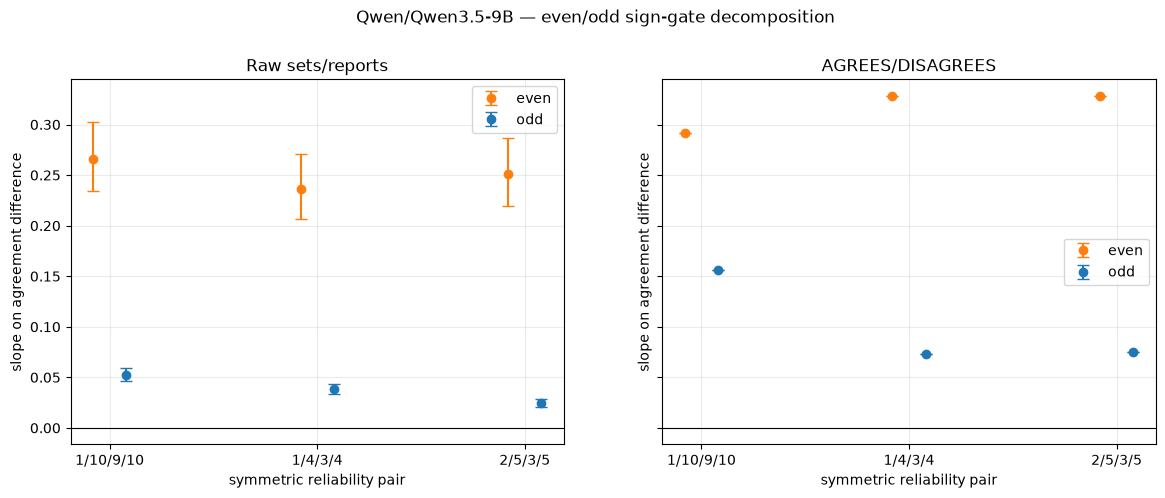

In [10]:
def symmetric_component_rows(
    rows: list[dict[str, object]], low: str, high: str
) -> list[dict[str, float | int]]:
    by_reliability = {
        reliability: {
            (int(row["question_set_index"]), int(row["answer_pattern_index"])): row
            for row in eligible_logit_rows(rows_at_reliability(rows, reliability))
        }
        for reliability in (low, high)
    }
    common = sorted(set(by_reliability[low]) & set(by_reliability[high]))
    paired = []
    for key in common:
        low_row = by_reliability[low][key]
        high_row = by_reliability[high][key]
        delta = agreement_difference(low_row)
        assert agreement_difference(high_row) == delta
        low_margin = float(low_row["candidate_1_minus_candidate_2_raw_logit"])
        high_margin = float(high_row["candidate_1_minus_candidate_2_raw_logit"])
        paired.append({
            "question_set_index": key[0],
            "answer_pattern_index": key[1],
            "delta_agreement": delta,
            "low_margin": low_margin,
            "high_margin": high_margin,
            "even": 0.5 * (high_margin + low_margin),
            "odd": 0.5 * (high_margin - low_margin),
        })
    return paired


def component_slope(
    rows: list[dict[str, float | int]], component: str
) -> float:
    fit = linear_fit(
        [float(row["delta_agreement"]) for row in rows],
        [float(row[component]) for row in rows],
    )
    return float(fit["slope"])


def percentile(values: list[float], probability: float) -> float:
    ordered = sorted(value for value in values if math.isfinite(value))
    if not ordered:
        return float("nan")
    position = probability * (len(ordered) - 1)
    lower = math.floor(position)
    upper = math.ceil(position)
    if lower == upper:
        return ordered[lower]
    weight = position - lower
    return ordered[lower] * (1 - weight) + ordered[upper] * weight


def clustered_slope_interval(
    rows: list[dict[str, float | int]], component: str, *, seed: int
) -> tuple[float, float]:
    by_schedule = {
        index: [row for row in rows if row["question_set_index"] == index]
        for index in range(NUM_QUESTION_SETS)
    }
    assert all(by_schedule.values())
    rng = random.Random(seed)
    slopes = []
    for _ in range(SIGN_GATE_BOOTSTRAP_REPLICATES):
        sampled = []
        for _ in range(NUM_QUESTION_SETS):
            sampled.extend(by_schedule[rng.randrange(NUM_QUESTION_SETS)])
        slopes.append(component_slope(sampled, component))
    return percentile(slopes, 0.025), percentile(slopes, 0.975)


sign_gate_rows = []
for model_index, model_id in enumerate(MODEL_IDS):
    for representation_index, representation in enumerate(REPRESENTATIONS):
        rows = balanced_results_by_model[model_id][representation]
        for pair_index, (low, high) in enumerate(SYMMETRIC_R_PAIRS):
            paired = symmetric_component_rows(rows, low, high)
            for component_index, component in enumerate(("even", "odd")):
                fit = linear_fit(
                    [float(row["delta_agreement"]) for row in paired],
                    [float(row[component]) for row in paired],
                )
                lower, upper = clustered_slope_interval(
                    paired, component,
                    seed=(
                        SEED + 1000 * model_index + 100 * representation_index
                        + 10 * pair_index + component_index
                    ),
                )
                sign_gate_rows.append({
                    "model": model_id,
                    "representation": representation,
                    "low_r": low,
                    "high_r": high,
                    "component": component,
                    "n": fit["n"],
                    "intercept": fit["intercept"],
                    "slope": fit["slope"],
                    "slope_ci_2.5%": lower,
                    "slope_ci_97.5%": upper,
                    "mean_abs_odd_symmetry_residual": fmean(
                        abs(float(row["low_margin"]) + float(row["high_margin"]))
                        for row in paired
                    ),
                })
        null_fit = correlation_summary(rows_at_reliability(rows, NULL_R))
        sign_gate_rows.append({
            "model": model_id,
            "representation": representation,
            "low_r": NULL_R,
            "high_r": NULL_R,
            "component": "continuous_null",
            "n": null_fit["n"],
            "intercept": null_fit["intercept"],
            "slope": null_fit["slope"],
            "slope_ci_2.5%": None,
            "slope_ci_97.5%": None,
            "mean_abs_odd_symmetry_residual": None,
        })

display(sign_gate_rows)

for model_id in MODEL_IDS:
    fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(14, 5), sharey=True)
    for axis, representation in zip(axes, REPRESENTATIONS):
        selected = [
            row for row in sign_gate_rows
            if row["model"] == model_id and row["representation"] == representation
            and row["component"] in {"even", "odd"}
        ]
        for component, offset, color in (("even", -0.08, "tab:orange"), ("odd", 0.08, "tab:blue")):
            component_rows = [row for row in selected if row["component"] == component]
            x_values = [index + offset for index in range(len(component_rows))]
            slopes = [float(row["slope"]) for row in component_rows]
            axis.errorbar(
                x_values, slopes,
                yerr=[
                    [slope - float(row["slope_ci_2.5%"]) for slope, row in zip(slopes, component_rows)],
                    [float(row["slope_ci_97.5%"]) - slope for slope, row in zip(slopes, component_rows)],
                ],
                fmt="o", capsize=4, color=color, label=component,
            )
        axis.axhline(0, color="black", linewidth=0.8)
        axis.set(
            title=representation_label(representation),
            xlabel="symmetric reliability pair",
            xticks=range(len(SYMMETRIC_R_PAIRS)),
            xticklabels=[f"{low}/{high}" for low, high in SYMMETRIC_R_PAIRS],
            ylabel="slope on agreement difference",
        )
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle(f"{model_id} — even/odd sign-gate decomposition")
    fig.subplots_adjust(top=0.84, wspace=0.2)
    plt.show()

## Completion and compliance diagnostics

Both prompt representations request an immediate terminal answer, so reasoning length is not an experimental axis. These summaries compare completion length, answer-boundary availability, semantic compliance, and exact-format compliance while retaining malformed completions.

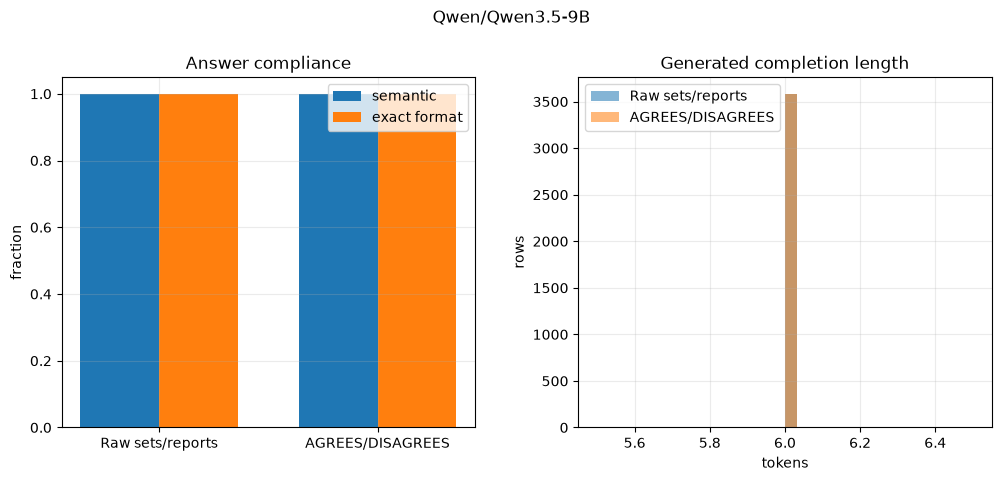

{'Qwen/Qwen3.5-9B': {'raw': {'rows': 3584,
   'semantic_compliance_rate': 1.0,
   'exact_format_compliance_rate': 1.0,
   'answer_marker_rate': 1.0,
   'boundary_available_rate': 1.0,
   'generated_length_mean': 6.0,
   'generated_length_min': 6,
   'generated_length_max': 6,
   'hit_completion_cap': 0,
   'answer_whitespace_forms': {"' ' + candidate + ''": 3584},
   'compliance_breaks': {'compliant': 3584}},
  'candidate_evidence': {'rows': 3584,
   'semantic_compliance_rate': 1.0,
   'exact_format_compliance_rate': 1.0,
   'answer_marker_rate': 1.0,
   'boundary_available_rate': 1.0,
   'generated_length_mean': 6.0,
   'generated_length_min': 6,
   'generated_length_max': 6,
   'hit_completion_cap': 0,
   'answer_whitespace_forms': {"' ' + candidate + ''": 3584},
   'compliance_breaks': {'compliant': 3584}}}}

In [11]:
def completion_statistics(rows: list[dict[str, object]]) -> dict[str, object]:
    generated_lengths = [len(row["generated_token_ids"]) for row in rows]
    return {
        "rows": len(rows),
        "semantic_compliance_rate": fmean(
            float(row["semantic_answer_compliance"]) for row in rows
        ),
        "exact_format_compliance_rate": fmean(
            float(row["exact_answer_format_compliance"]) for row in rows
        ),
        "answer_marker_rate": fmean(
            float(row["answer_marker_present"]) for row in rows
        ),
        "boundary_available_rate": fmean(
            float(row["answer_boundary_generated_token_count"] is not None)
            for row in rows
        ),
        "generated_length_mean": fmean(generated_lengths),
        "generated_length_min": min(generated_lengths),
        "generated_length_max": max(generated_lengths),
        "hit_completion_cap": sum(
            bool(row["completion"]["hit_token_cap"]) for row in rows
        ),
        "answer_whitespace_forms": dict(Counter(
            f"{row['answer_leading_whitespace']!r} + candidate + "
            f"{row['answer_trailing_whitespace']!r}"
            for row in rows if row["semantic_answer_compliance"]
        )),
        "compliance_breaks": dict(Counter(
            row["compliance_break"] or "compliant" for row in rows
        )),
    }


completion_statistics_by_model = {
    model_id: {
        representation: completion_statistics(
            results_by_model[model_id][representation]
        )
        for representation in REPRESENTATIONS
    }
    for model_id in MODEL_IDS
}

for model_id in MODEL_IDS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    labels = [representation_label(value) for value in REPRESENTATIONS]
    semantic = [
        completion_statistics_by_model[model_id][value]["semantic_compliance_rate"]
        for value in REPRESENTATIONS
    ]
    exact = [
        completion_statistics_by_model[model_id][value]["exact_format_compliance_rate"]
        for value in REPRESENTATIONS
    ]
    x_values = list(range(len(REPRESENTATIONS)))
    axes[0].bar([value - 0.18 for value in x_values], semantic, width=0.36, label="semantic")
    axes[0].bar([value + 0.18 for value in x_values], exact, width=0.36, label="exact format")
    axes[0].set(xticks=x_values, xticklabels=labels, ylim=(0, 1.05), ylabel="fraction")
    axes[0].set_title("Answer compliance")
    axes[0].legend()
    for representation in REPRESENTATIONS:
        lengths = [
            len(row["generated_token_ids"])
            for row in results_by_model[model_id][representation]
        ]
        axes[1].hist(
            lengths, bins=min(30, max(5, int(math.sqrt(len(lengths))))),
            alpha=0.55, label=representation_label(representation),
        )
    axes[1].set(title="Generated completion length", xlabel="tokens", ylabel="rows")
    axes[1].legend()
    for axis in axes:
        axis.grid(alpha=0.25)
    fig.suptitle(model_id)
    fig.subplots_adjust(top=0.84, wspace=0.25)
    plt.show()

completion_statistics_by_model

## Raw wide truth tables

One CSV is exported per model, prompt representation, and fixed reliability. Each question-schedule column group includes the two agreement counts already stored in the transcript row, the two answer logits, their contrast, and boundary availability. No candidate-specific factor list is recomputed.

In [12]:
def format_optional(value: object) -> str:
    return "" if value is None else f"{float(value):.8f}"


def raw_truth_table(rows: list[dict[str, object]]) -> tuple[list[str], list[list[str]]]:
    by_key = {
        (int(row["answer_pattern_index"]), int(row["question_set_index"])): row
        for row in rows
    }
    headers = ["answer_pattern", *[f"report_i{i}" for i in range(1, K + 1)]]
    for j in range(1, NUM_QUESTION_SETS + 1):
        headers.extend([
            f"agreement_j{j}_c1", f"agreement_j{j}_c2",
            f"raw_logit_j{j}_c1", f"raw_logit_j{j}_c2",
            f"raw_logit_j{j}_c1_minus_c2", f"has_boundary_logits_j{j}",
        ])
    matrix = []
    for pattern_index, reports in enumerate(answer_patterns(K)):
        pattern = "".join("Y" if report == "YES" else "N" for report in reports)
        output = [pattern, *reports]
        for question_set_index in range(NUM_QUESTION_SETS):
            row = by_key[(pattern_index, question_set_index)]
            output.extend([
                str(row["total_agreement_candidate_1"]),
                str(row["total_agreement_candidate_2"]),
                format_optional(row["candidate_1_raw_logit"]),
                format_optional(row["candidate_2_raw_logit"]),
                format_optional(row["candidate_1_minus_candidate_2_raw_logit"]),
                str(bool(row["pair_has_answer_boundary_logits"])),
            ])
        matrix.append(output)
    return headers, matrix


truth_tables_by_model = {}
for model_id in MODEL_IDS:
    truth_tables_by_model[model_id] = {}
    output_dir = EXPERIMENT_ROOT / model_key(model_id)
    for representation in REPRESENTATIONS:
        truth_tables_by_model[model_id][representation] = {}
        for reliability_exact in R_EXACT_VALUES:
            headers, matrix = raw_truth_table(rows_at_reliability(
                balanced_results_by_model[model_id][representation], reliability_exact
            ))
            truth_tables_by_model[model_id][representation][reliability_exact] = {
                "headers": headers, "rows": matrix
            }
            reliability_slug = reliability_exact.replace("/", "_of_")
            path = output_dir / representation / (
                f"agreement_truth_table_reliability_{reliability_slug}.csv"
            )
            with path.open("w", newline="", encoding="utf-8") as handle:
                writer = csv.writer(handle, lineterminator="\n")
                writer.writerow(headers)
                writer.writerows(matrix)


def display_truth_table(representation: str, reliability_exact: str) -> None:
    for model_id in MODEL_IDS:
        table = truth_tables_by_model[model_id][representation][reliability_exact]
        print(
            f"{model_id} — {representation_label(representation)} — "
            f"reliability {reliability_exact}: {len(table['rows'])} patterns"
        )
        display(table["rows"][:2])


truth_representation_widget = representation_selector()
truth_reliability_widget = reliability_selector()
truth_output = widgets.interactive_output(
    display_truth_table,
    {
        "representation": truth_representation_widget,
        "reliability_exact": truth_reliability_widget,
    },
)
display(widgets.VBox([
    widgets.HBox([truth_representation_widget, truth_reliability_widget]),
    truth_output,
]))

## Compact completion and prompt audit

The audit view exposes one unmodified completion, prompt, agreement vectors, positional metadata, generated IDs, boundary metadata, compliance outcome, and—only for the reduced representation—the candidate-evidence structure. Raw sets and reports are read from ordinary raw fields or reduced-row audit metadata without changing what the model saw.

In [17]:
def display_audit_view(representation: str) -> None:
    for model_id in MODEL_IDS:
        rows = results_by_model[model_id][representation]
        sample = next(
            (row for row in rows if not row["strict_answer_compliance"]), rows[1230]
        )
        print(f"{model_id} — {representation_label(representation)}")
        display({
            "row_id": sample["row_id"],
            "source_row_id": sample.get("source_row_id"),
            "reliability": row_reliability_exact(sample),
            "presentation_order": sample["presentation_order"],
            "membership_sets_audit": row_membership_sets(sample),
            "observed_reports_audit": row_observed_reports(sample),
            "agreement_c1": sample["agreement_candidate_1_by_question"],
            "agreement_c2": sample["agreement_candidate_2_by_question"],
            "candidate_evidence": sample.get("candidate_evidence"),
            "serialized_prompt": sample["serialized_prompt"],
            "full_completion": sample["full_completion"],
            "generated_token_ids": sample["generated_token_ids"],
            "generated_sequence_token_ids": sample["generated_sequence_token_ids"],
            "answer_boundary_source": sample["answer_boundary_source"],
            "answer_boundary_generated_token_count": sample[
                "answer_boundary_generated_token_count"
            ],
            "answer_value_generated_token_ids": sample[
                "answer_value_generated_token_ids"
            ],
            "terminal_stop_token_id": sample["completion"].get(
                "terminal_stop_token_id"
            ),
            "semantic_answer_compliance": sample["semantic_answer_compliance"],
            "exact_answer_format_compliance": sample[
                "exact_answer_format_compliance"
            ],
            "strict_answer_compliance": sample["strict_answer_compliance"],
            "compliance_break": sample["compliance_break"],
            "answer_boundary_break": sample["answer_boundary_break"],
            "candidate_1_raw_logit": sample["candidate_1_raw_logit"],
            "candidate_2_raw_logit": sample["candidate_2_raw_logit"],
            "activation_path": sample.get("activation_path"),
        })


audit_widget = representation_selector()
audit_output = widgets.interactive_output(
    display_audit_view, {"representation": audit_widget}
)
display(widgets.VBox([audit_widget, audit_output]))